In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/amitkumarverma/Desktop/ecommerce-sales-analysis/data/Sample-Superstore.csv", encoding='latin1')

print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [18]:
# Check basic info
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [19]:
# Convert dates to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# New useful columns
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Shipping Days,Profit Margin (%)
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,7,11.25


In [20]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Order Month,Shipping Days,Profit Margin (%)
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,3.958175,12.031393
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,0.000000,-275.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,3.000000,7.500000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,4.000000,27.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,5.000000,36.250000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,7.000000,50.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,1.747567,46.675435


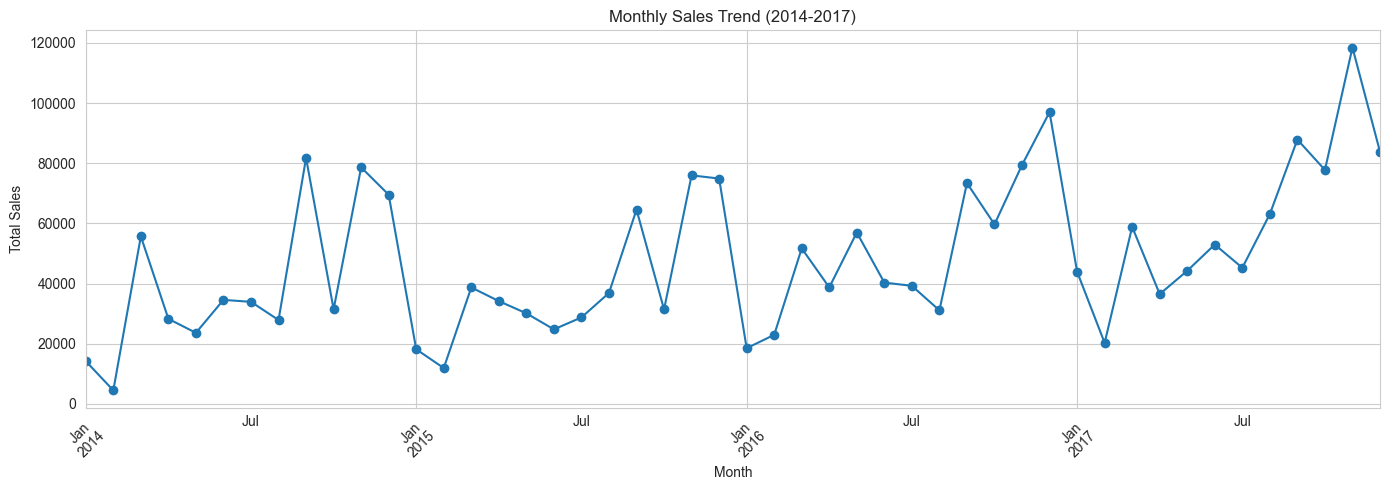

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Monthly sales trend
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend (2014-2017)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


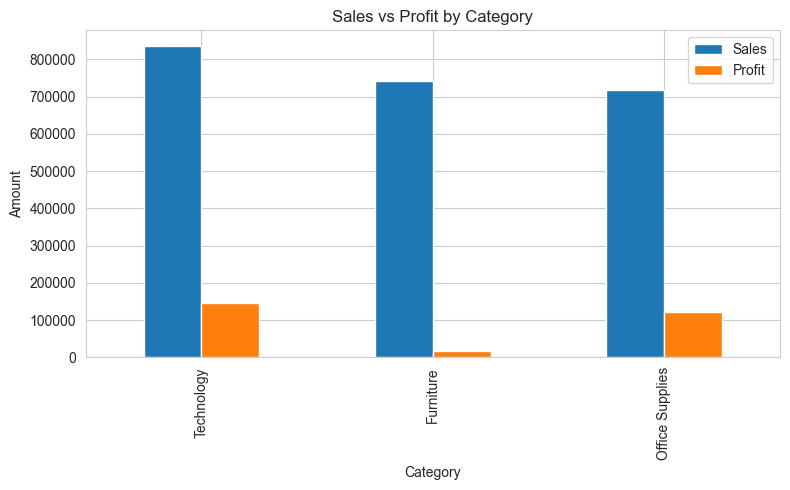

In [24]:
category_summary = df.groupby('Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
print(category_summary)

category_summary.plot(kind='bar', figsize=(8,5))
plt.title('Sales vs Profit by Category')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()


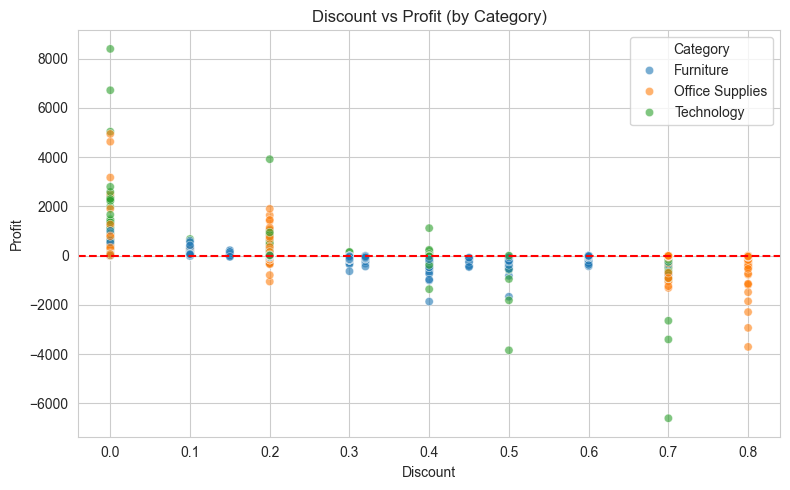

In [25]:
# Discount vs Profit relationship
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Discount vs Profit (by Category)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

In [26]:
# Top 10 most profitable products
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
print("TOP 10 PROFITABLE PRODUCTS:\n", top_products)

# Top 10 loss-making products
loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
print("\nTOP 10 LOSS-MAKING PRODUCTS:\n", loss_products)

TOP 10 PROFITABLE PRODUCTS:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

TOP 10 LOSS-MAKING PRODUCTS:

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303


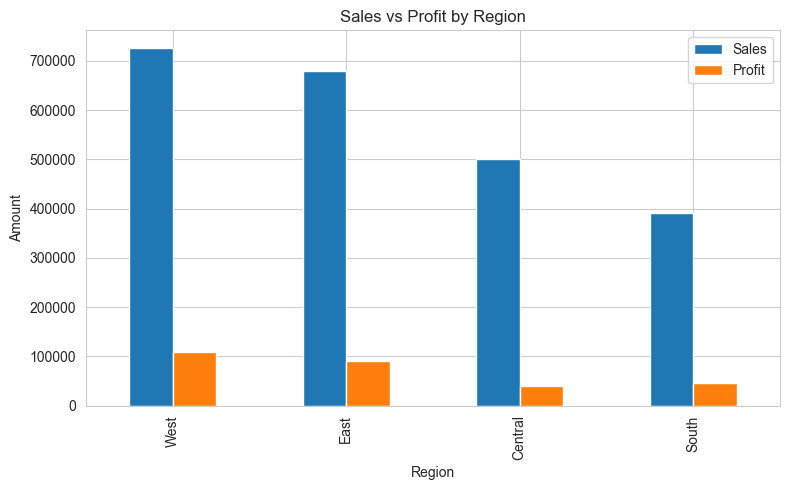

In [27]:
region_summary = df.groupby('Region')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)
print(region_summary)

region_summary.plot(kind='bar', figsize=(8,5))
plt.title('Sales vs Profit by Region')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

In [28]:
state_summary = df.groupby('State')[['Sales','Profit']].sum().sort_values('Sales', ascending=False).head(10)
print(state_summary)

                    Sales      Profit
State                                
California    457687.6315  76381.3871
New York      310876.2710  74038.5486
Texas         170188.0458 -25729.3563
Washington    138641.2700  33402.6517
Pennsylvania  116511.9140 -15559.9603
Florida        89473.7080  -3399.3017
Illinois       80166.1010 -12607.8870
Ohio           78258.1360 -16971.3766
Michigan       76269.6140  24463.1876
Virginia       70636.7200  18597.9504


In [29]:
import datetime as dt

# Reference date (1 din baad last order date ke)
reference_date = df['Order Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (reference_date - x.max()).days,   # Recency
    'Order ID': 'nunique',                                      # Frequency
    'Sales': 'sum'                                               # Monetary
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
print(rfm.head())
print(rfm.describe())

  Customer ID  Recency  Frequency  Monetary
0    AA-10315      185          5  5563.560
1    AA-10375       20          9  1056.390
2    AA-10480      260          4  1790.512
3    AA-10645       56          6  5086.935
4    AB-10015      416          3   886.156
           Recency   Frequency      Monetary
count   793.000000  793.000000    793.000000
mean    147.802018    6.316520   2896.848500
std     186.211051    2.550885   2628.670117
min       1.000000    1.000000      4.833000
25%      31.000000    5.000000   1146.050000
50%      76.000000    6.000000   2256.394000
75%     184.000000    8.000000   3785.276000
max    1166.000000   17.000000  25043.050000


In [30]:
# Score each metric 1-5 (5 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm.head()


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,AA-10315,185,5,5563.560,2,2,5,9
1,AA-10375,20,9,1056.390,5,5,2,12
2,AA-10480,260,4,1790.512,1,1,3,5
3,AA-10645,56,6,5086.935,3,3,5,11
4,AB-10015,416,3,886.156,1,1,1,3


In [31]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalist'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print(rfm['Segment'].value_counts())

Segment
Loyal Customers       254
Potential Loyalist    219
Champions             124
At Risk               116
Lost                   80
Name: count, dtype: int64


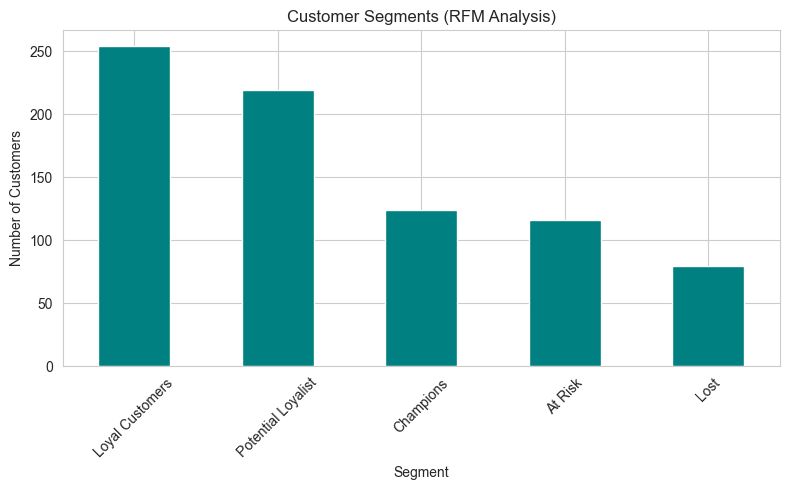

In [32]:
plt.figure(figsize=(8,5))
rfm['Segment'].value_counts().plot(kind='bar', color='teal')
plt.title('Customer Segments (RFM Analysis)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

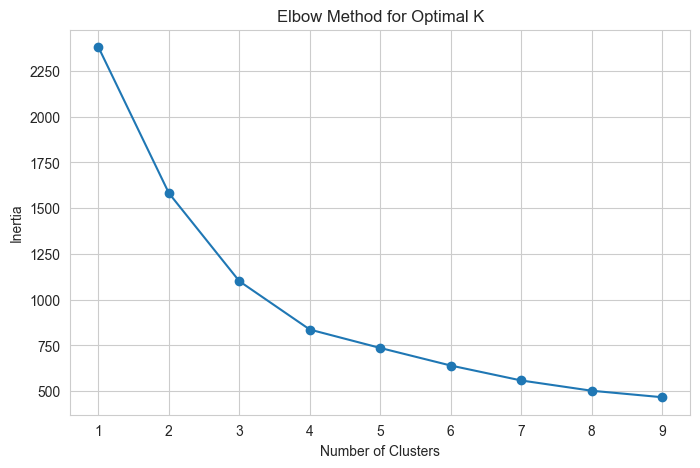

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# Elbow method to find best K
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [34]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)
print(rfm['Cluster'].value_counts())

            Recency  Frequency     Monetary
Cluster                                    
0         72.741611   8.516779  3322.222985
1        101.197015   4.731343  1669.688290
2        123.718750   8.296875  9479.545687
3        559.489583   3.697917  1470.228226
Cluster
1    335
0    298
3     96
2     64
Name: count, dtype: int64


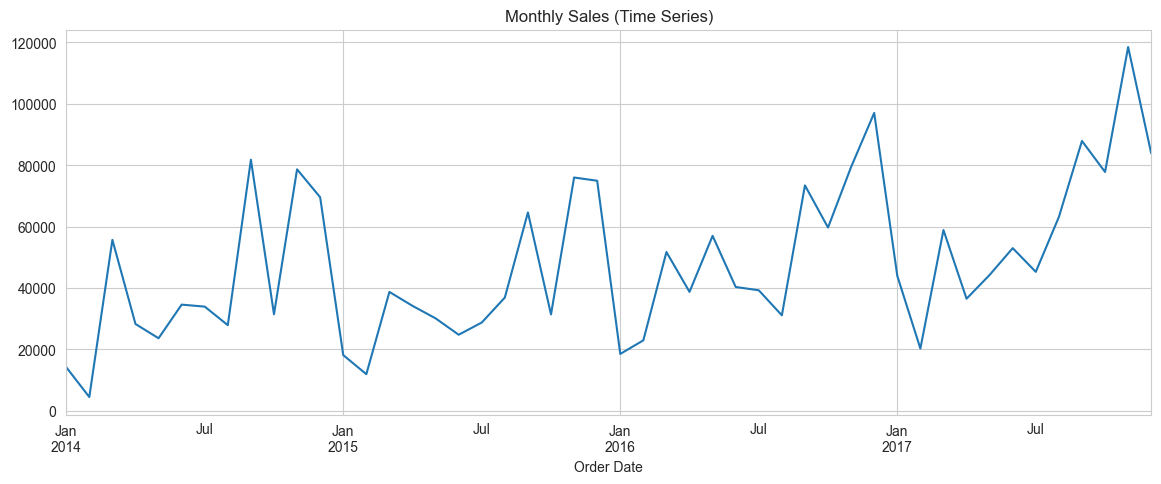

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -539.895
Date:                Tue, 07 Jul 2026   AIC                           1085.789
Time:                        12:26:10   BIC                           1091.340
Sample:                    01-01-2014   HQIC                          1087.878
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2278      0.262      0.868      0.386      -0.287       0.742
ma.L1         -0.8396      0.140     -5.979      0.000      -1.115      -0.564
sigma2      5.976e+08   6.93e-11   8.63e+18      0.0

In [37]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Prepare monthly sales series
monthly_sales_ts = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales_ts.index = monthly_sales_ts.index.to_timestamp()

plt.figure(figsize=(14,5))
monthly_sales_ts.plot()
plt.title('Monthly Sales (Time Series)')
plt.show()

# Fit ARIMA model
model = ARIMA(monthly_sales_ts, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

In [38]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)
print(rfm['Cluster'].value_counts())

            Recency  Frequency     Monetary
Cluster                                    
0         72.741611   8.516779  3322.222985
1        101.197015   4.731343  1669.688290
2        123.718750   8.296875  9479.545687
3        559.489583   3.697917  1470.228226
Cluster
1    335
0    298
3     96
2     64
Name: count, dtype: int64


In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Seasonal ARIMA - order=(p,d,q), seasonal_order=(P,D,Q,s) where s=12 (yearly seasonality)
sarima_model = SARIMAX(monthly_sales_ts, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -383.310
Date:                            Tue, 07 Jul 2026   AIC                            776.621
Time:                                    12:30:53   BIC                            784.398
Sample:                                01-01-2014   HQIC                           779.305
                                     - 12-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5056      0.238      2.125      0.034       0.039       0.972
ma.L1         -0.8922      0.188   

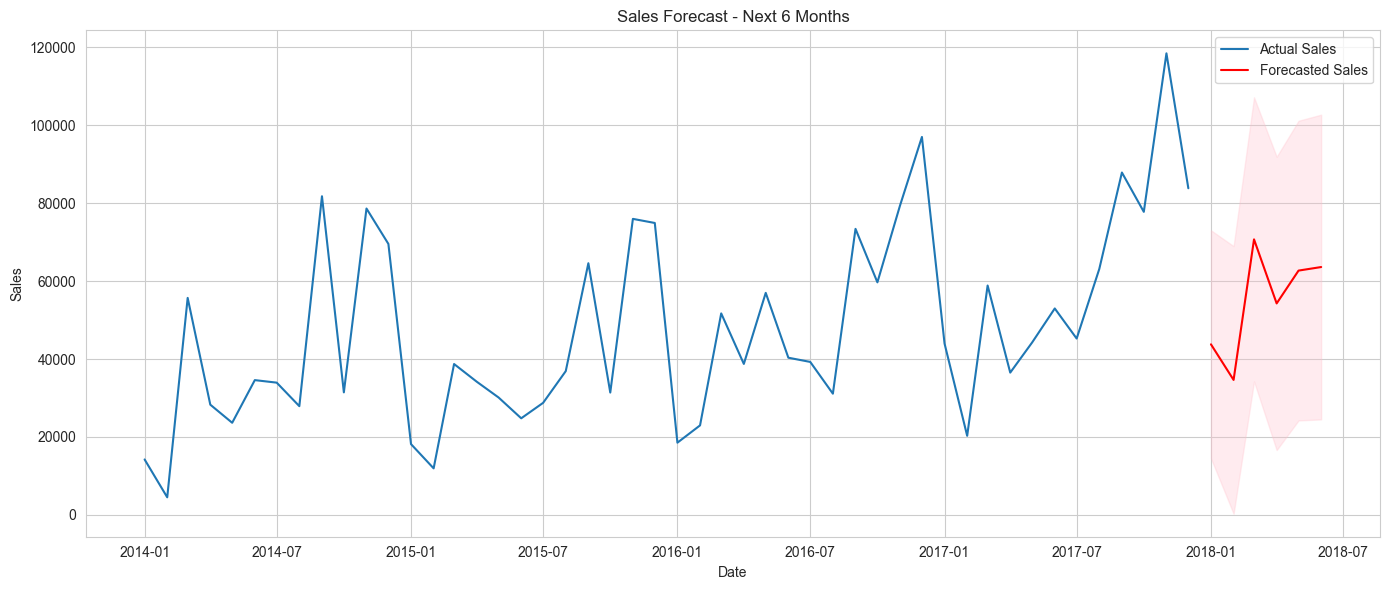

2018-01-01    43779.923953
2018-02-01    34645.617805
2018-03-01    70715.336413
2018-04-01    54275.318699
2018-05-01    62701.487279
2018-06-01    63612.261364
Freq: MS, Name: predicted_mean, dtype: float64


In [40]:
forecast_steps = 6
forecast = sarima_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales_ts.index, monthly_sales_ts.values, label='Actual Sales')
plt.plot(forecast_mean.index, forecast_mean.values, label='Forecasted Sales', color='red')
plt.fill_between(forecast_ci.index, 
                  forecast_ci.iloc[:,0], 
                  forecast_ci.iloc[:,1], color='pink', alpha=0.3)
plt.title('Sales Forecast - Next 6 Months')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

print(forecast_mean)

In [41]:
df.to_csv('../data/processed_data.csv', index=False)
rfm.to_csv('../data/rfm_data.csv', index=False)

In [42]:
forecast_df = pd.DataFrame({
    'Date': forecast_mean.index.strftime('%Y-%m-%d'),
    'Forecast': forecast_mean.values
})
forecast_df.to_csv('../data/forecast.csv', index=False)
print(forecast_df)

         Date      Forecast
0  2018-01-01  43779.923953
1  2018-02-01  34645.617805
2  2018-03-01  70715.336413
3  2018-04-01  54275.318699
4  2018-05-01  62701.487279
5  2018-06-01  63612.261364
